# 08 — Multi-window structural state: moving averages + crossovers

The structural-router and distillation notebooks (ewm-state-machine 21–22) give the router a **single-step** structural reading
(bss, D/R/N, ring). This notebook mimics a **moving-average view**: the
state now also carries the structural series' moving averages over the
last 2/3/4/5 steps, plus **crossover events** where a short window
crosses a long window from below (`..._up`) or from above (`..._down`)
— the same idea as fast/slow MA crosses, but over the HLLSet
trajectory (cf. the `ewm-scene ma` fast/slow BSSτ windows).

Plan:

1. run the prompted teacher with the extended state and check whether
   the window/crossover context changes its decisions,
2. visualise the fast/slow MAs and their crossings,
3. train the typed head on the extended structural features (still no
   query identity) and compare against the distillation notebook's structural-only
   baseline (67% holdout).

The loop-side machinery is `_structural_state` in `trainer/loop.py`;
the prompted router renders the new fields in `structural_decision_prompt`.

In [1]:
import os, sys, json

# Same GPU pin as notebooks 21–22: with PCI_BUS_ID on this machine the
# Quadro M1200 is device 0 and the RTX 3060 is device 1.
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
os.environ.setdefault("HF_HUB_DISABLE_PROGRESS_BARS", "1")

import numpy as np
import torch
import torch.nn as nn

EWM_SM = "/home/alexmy/SGS/SGS_lib/fractal_manifold_gen2/ewm-state-machine"
sys.path.insert(0, EWM_SM)

from trainer import (
    DecisionRecord,
    DecisionRouter,
    EwmScene,
    JevAdapter,
    LlmAdapter,
    StructuralLlmRouter,
    run_open_loop,
    run_jev_loop,
)

WORK = "/home/alexmy/.cache/ewm-window-crossings"
os.makedirs(WORK, exist_ok=True)
ewm = EwmScene()
print("torch sees:", torch.cuda.get_device_name(0),
      round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), "GB")
print("work:", WORK)

torch sees: NVIDIA GeForce RTX 3060 12.5 GB
work: /home/alexmy/.cache/ewm-window-crossings


In [2]:
QUERIES = [
    "What is the capital of France?",
    "Explain the intuition behind general relativity in three sentences.",
    "Write a haiku about rain.",
    "What is 17 * 24?",
    "Compare supervised and unsupervised learning briefly.",
    "What is the speed of light?",
    "Define entropy in simple words.",
    "Summarize the plot of Romeo and Juliet.",
]

adapter = LlmAdapter(max_new_tokens=32)
teacher = StructuralLlmRouter(max_new_tokens=128)   # prompt is longer now
jev     = JevAdapter(mock=True)

print("adapter names:", adapter.names)
print("teacher mode:", "mock" if teacher.mock else "real", "|", teacher.model_id)

adapter names: ('llm_a', 'llm_b', 'llm_c')
teacher mode: real | Qwen/Qwen2.5-1.5B-Instruct


## §1 — Extended-state teacher loop (windows + crossings in the prompt)

In [3]:
open_result = run_open_loop(adapter, ewm, QUERIES, WORK, cycles=2, max_new_tokens=32)
print("IICA:", open_result.same_union, "| BSS:", open_result.M_ol.shape,
      "| period:", open_result.period, "(true 8)")

IICA: False | BSS: (16, 3) | period: 8.0 (true 8)


In [4]:
teacher_result = run_jev_loop(
    adapter, teacher, ewm, open_result, QUERIES, WORK, T=24, max_new_tokens=32,
    structural=True, ingest_decision=True,
)
data = teacher_result.routing_log
print()
print("teacher decision distribution:")
for n in adapter.names:
    print(f"  {n:6s} {sum(1 for r in data if r['decision']['decision'] == n):2d} steps")

# show the extended state the router saw at a late step
late = data[-1]
print()
print("late-state keys:", sorted(late["state"].keys()))
print("windows (first 6):", dict(list((late["state"].get("windows") or {}).items())[:6]))
cross = late["state"].get("crossings") or {}
print("crossings (true events):", sorted(k for k, v in cross.items() if v))

with open(f"{WORK}/window_dataset.jsonl", "w") as fh:
    for r in data:
        fh.write(json.dumps(r) + "\n")
print("saved:", f"{WORK}/window_dataset.jsonl", f"({len(data)} labelled states)")

t= 0 q=0  route=llm_c   confidence=1.000  gated=False  mock=False


t= 4 q=4  route=llm_b   confidence=0.900  gated=False  mock=False


t= 8 q=0  route=llm_b   confidence=0.900  gated=False  mock=False


t=12 q=4  route=llm_b   confidence=0.900  gated=False  mock=False


t=16 q=0  route=llm_b   confidence=0.900  gated=False  mock=False


t=20 q=4  route=llm_b   confidence=0.900  gated=False  mock=False


t=23 q=7  route=llm_b   confidence=0.000  gated=False  mock=False

teacher decision distribution:
  llm_a   0 steps
  llm_b  17 steps
  llm_c   7 steps

late-state keys: ['bss', 'crossings', 'drn', 'memory', 'query', 'ring', 'step', 'windows']
windows (first 6): {'np_ma2': 67.0, 'np_ma3': 79.3333, 'np_ma4': 63.75, 'np_ma5': 58.8, 'rp_ma2': 29.5, 'rp_ma3': 21.6667}
crossings (true events): ['bss_llm_c_x2x4_up', 'dp_x3x5_up', 'ind1_x2x4_up', 'ind3_x2x4_down', 'residual_x2x4_down', 'residual_x3x5_down', 'rotation_count_x3x5_down', 'rp_x2x4_up']
saved: /home/alexmy/.cache/ewm-window-crossings/window_dataset.jsonl (24 labelled states)


## §2 — Did the window/crossover context change the teacher?

In [5]:
# Per-step view: query -> decision, plus how many crossover events were
# live at that step (a proxy for 'the state was structurally active').
print(f"{'step':>4s} {'q':>2s} {'decision':>8s} {'crossings':>10s}  query")
for r in data:
    st = r["state"]
    cross = st.get("crossings") or {}
    n_cross = sum(1 for v in cross.values() if v)
    q = st.get("query", "")[:38]
    print(f"{r['step']:4d} {r['step'] % 8:2d} {r['decision']['decision']:>8s} "
          f"{n_cross:10d}  {q}")

# nb22's policy was: q=1 -> llm_b, everything else -> llm_c.
nb22_policy = {1: "llm_b"}
changed = sum(1 for r in data
              if r["decision"]["decision"] != nb22_policy.get(r["step"] % 8, "llm_c"))
print()
print(f"steps where the extended state changed the decision vs the nb22 policy: {changed}/{len(data)}")

step  q decision  crossings  query
   0  0    llm_c          0  What is the capital of France?
   1  1    llm_b          0  Explain the intuition behind general r
   2  2    llm_c          0  Write a haiku about rain.
   3  3    llm_c          7  What is 17 * 24?
   4  4    llm_b         16  Compare supervised and unsupervised le
   5  5    llm_b         12  What is the speed of light?
   6  6    llm_b         10  Define entropy in simple words.
   7  7    llm_b          7  Summarize the plot of Romeo and Juliet
   8  0    llm_b          9  What is the capital of France?
   9  1    llm_b          9  Explain the intuition behind general r
  10  2    llm_c         12  Write a haiku about rain.
  11  3    llm_c          6  What is 17 * 24?
  12  4    llm_b          4  Compare supervised and unsupervised le
  13  5    llm_b          8  What is the speed of light?
  14  6    llm_b         10  Define entropy in simple words.
  15  7    llm_b          7  Summarize the plot of Romeo and Juliet

## §3 — Fast/slow moving averages and their crossings

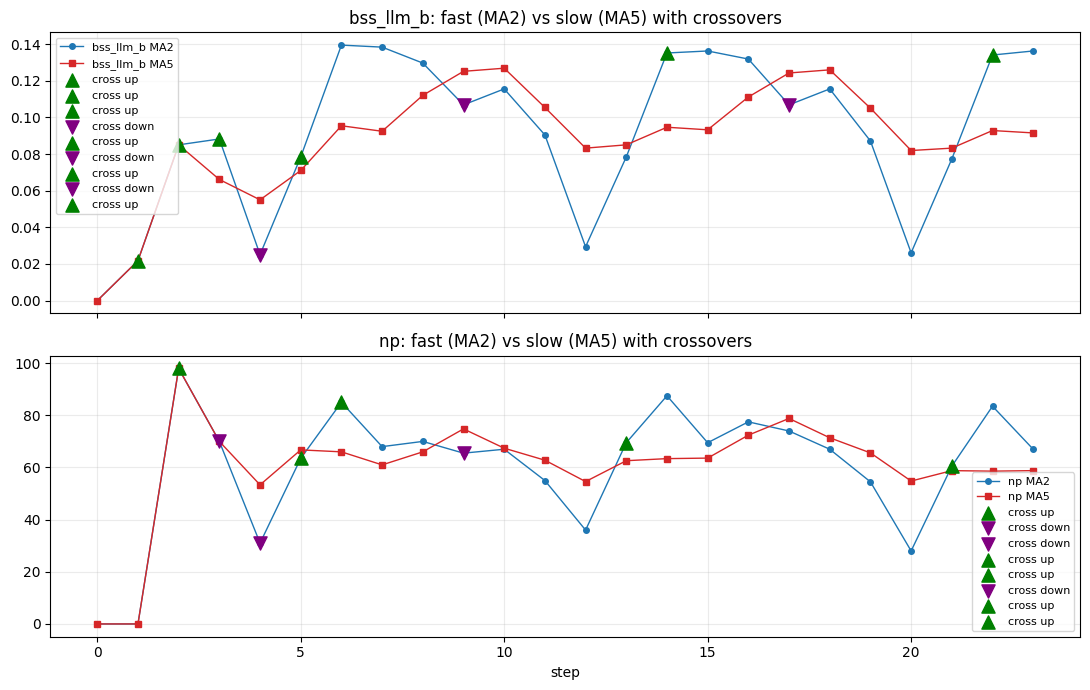

In [6]:
%matplotlib inline
import matplotlib.pyplot as plt

# Reconstruct per-step MA series from the routing log (each state carries
# its own windows), then mark crossings of MA2 vs MA5.
steps = [r["step"] for r in data]
w = [r["state"].get("windows") or {} for r in data]

def series_of(feat):
    return [x.get(f"{feat}_ma2", 0.0) for x in w], [x.get(f"{feat}_ma5", 0.0) for x in w]

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
for ax, feat in ((axes[0], "bss_llm_b"), (axes[1], "np")):
    ma2, ma5 = series_of(feat)
    ax.plot(steps, ma2, "o-", lw=1.0, ms=4, color="tab:blue", label=f"{feat} MA2")
    ax.plot(steps, ma5, "s-", lw=1.0, ms=4, color="tab:red", label=f"{feat} MA5")
    for t in range(1, len(steps)):
        if ma2[t - 1] <= ma5[t - 1] < ma2[t]:
            ax.scatter([steps[t]], [ma2[t]], marker="^", s=90, color="green",
                       label="cross up" if t == 1 or True else "", zorder=5)
        if ma2[t - 1] >= ma5[t - 1] > ma2[t]:
            ax.scatter([steps[t]], [ma2[t]], marker="v", s=90, color="purple",
                       label="cross down" if t == 1 or True else "", zorder=5)
    ax.set_title(f"{feat}: fast (MA2) vs slow (MA5) with crossovers")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.25)
axes[1].set_xlabel("step")
plt.tight_layout()
plt.savefig(f"{WORK}/window_crossings.png", dpi=110)
plt.show()

## §4 — Typed head on the extended structural features (still no query identity)

In [7]:
OPTION_ORDER = sorted(adapter.names)
CORE = ["bss_llm_a", "bss_llm_b", "bss_llm_c", "np", "rp", "dp",
        "residual", "dim", "spill_first"]

def structural_features(state):
    bss  = state.get("bss") or {}
    drn  = state.get("drn") or {}
    ring = state.get("ring") or {}
    t = float(state.get("step", 0))
    ph = 2.0 * np.pi * t / 8.0
    feats = [float(bss.get(n, 0.0)) for n in OPTION_ORDER]
    feats += [float(drn.get("dp", 0)), float(drn.get("rp", 0)),
              float(drn.get("np", 0)), float(drn.get("ind1", 0)),
              float(drn.get("ind3", 0))]
    feats += [float(ring.get("residual", 0)), float(ring.get("in_span", False)),
              float(ring.get("dim", 0)), float(ring.get("rotation_count", 0)),
              float(ring.get("spill_first", 0))]
    feats += [np.sin(ph), np.cos(ph), t / 16.0, 1.0]
    return np.asarray(feats, dtype=np.float32)

def extended_features(state):
    """structural (17) + MA2/MA5 windows (18) + crossings (36) = 71."""
    f = list(structural_features(state))
    windows = state.get("windows") or {}
    crossings = state.get("crossings") or {}
    for name in CORE:
        f += [float(windows.get(f"{name}_ma2", 0.0)),
              float(windows.get(f"{name}_ma5", 0.0))]
    for name in CORE:
        for ks, kl in ((2, 4), (3, 5)):
            for d in ("up", "down"):
                f.append(1.0 if crossings.get(f"{name}_x{ks}x{kl}_{d}", False) else 0.0)
    return np.asarray(f, dtype=np.float32)

class TypedHead(nn.Module):
    def __init__(self, in_dim, n_options, hidden=16, dropout=0.4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, n_options),
        )
    def forward(self, x):
        return self.net(x)

def train_head(X, Y, seed=0, epochs=800):
    rng = np.random.default_rng(seed)
    y_cls = np.argmax(Y, axis=1)
    tr, te = [], []
    for c in np.unique(y_cls):
        idx_c = np.where(y_cls == c)[0]
        rng.shuffle(idx_c)
        n_tr_c = max(1, int(0.8 * len(idx_c)))
        tr += list(idx_c[:n_tr_c]); te += list(idx_c[n_tr_c:])
    tr, te = np.array(tr), np.array(te)
    mu, sd = X[tr].mean(axis=0), X[tr].std(axis=0) + 1e-9
    Xs = (X - mu) / sd
    torch.manual_seed(seed)
    model = TypedHead(X.shape[1], len(OPTION_ORDER))
    opt = torch.optim.Adam(model.parameters(), lr=2e-3, weight_decay=3e-3)
    Xtr = torch.tensor(Xs[tr]); Ytr = torch.tensor(Y[tr])
    Xte = torch.tensor(Xs[te]); Yte = torch.tensor(Y[te])
    for _ in range(epochs):
        opt.zero_grad()
        logp = torch.log_softmax(model(Xtr), dim=1)
        loss = torch.mean(torch.sum(-Ytr * logp, dim=1))
        loss.backward()
        opt.step()
    with torch.no_grad():
        p_te = torch.softmax(model(Xte), dim=1).numpy()
    acc = float(np.mean(np.argmax(p_te, axis=1) == np.argmax(Y[te], axis=1)))
    kl = float(np.mean(np.sum(Y[te] * (np.log(Y[te] + 1e-9) - np.log(p_te + 1e-9)), axis=1)))
    return model, mu, sd, te, p_te, acc, kl

Y = np.stack([[r["decision"]["probabilities"].get(n, 0.0)
              for n in OPTION_ORDER] for r in data])

X_base = np.stack([structural_features(r["state"]) for r in data])
X_ext  = np.stack([extended_features(r["state"]) for r in data])

_, _, _, _, _, acc_base, kl_base = train_head(X_base, Y)
print(f"structural-only (nb22 baseline): test argmax-acc {acc_base:.2f} | test KL {kl_base:.4f}")

head_ext, mu_e, sd_e, te_e, p_e, acc_ext, kl_ext = train_head(X_ext, Y)
print(f"+ windows/crossings           : test argmax-acc {acc_ext:.2f} | test KL {kl_ext:.4f}")

print()
print("held-out teacher vs extended head:")
for i in range(len(te_e)):
    print(f"  state {te_e[i]:2d}: teacher {np.round(Y[te_e[i]], 2)}  head {np.round(p_e[i], 2)}")

structural-only (nb22 baseline): test argmax-acc 0.67 | test KL 0.5647


+ windows/crossings           : test argmax-acc 0.67 | test KL 1.2731

held-out teacher vs extended head:
  state 21: teacher [0. 1. 0.]  head [0.03 0.89 0.09]
  state 13: teacher [0. 1. 0.]  head [0.13 0.44 0.43]
  state  4: teacher [0.  0.9 0.1]  head [0.12 0.23 0.65]
  state 22: teacher [0.1 0.8 0.1]  head [0.05 0.88 0.07]
  state  2: teacher [0. 0. 1.]  head [0.   0.99 0.01]
  state 10: teacher [0.1 0.1 0.8]  head [0.01 0.01 0.98]


## §5 — A/B: extended teacher vs extended head vs Jev-mock

In [8]:
class TypedHeadRouter(DecisionRouter):
    def __init__(self, model, feature_fn, option_order, mu, sd):
        self.model = model
        self.feature_fn = feature_fn
        self.option_order = list(option_order)
        self.mu = mu
        self.sd = sd
    def route(self, state, options, instructions, extra_noul=None):
        x = (self.feature_fn(state) - self.mu) / self.sd
        with torch.no_grad():
            logits = self.model(torch.tensor(x).unsqueeze(0))[0]
        p = torch.softmax(logits, dim=0).numpy()
        probs = {n: float(p[i]) for i, n in enumerate(self.option_order)}
        decision = max(probs, key=probs.get)
        return DecisionRecord(
            decision=decision, confidence=float(probs[decision]),
            probabilities=probs, decision_type="route_query", aux={},
            model="typed-head-window", mock=False,
        )

head_router = TypedHeadRouter(head_ext, extended_features, OPTION_ORDER, mu_e, sd_e)
head_result = run_jev_loop(
    adapter, head_router, ewm, open_result, QUERIES, WORK, T=8, max_new_tokens=32,
    structural=True, ingest_decision=True,
)

jev_result = run_jev_loop(
    adapter, jev, ewm, open_result, QUERIES, WORK, T=8, max_new_tokens=32,
    ingest_decision=True,
)

rows = [("teacher-ext", teacher_result), ("typed-head-ext", head_result), ("jev-mock", jev_result)]
print(f"{'router':14s} {'choice distribution':30s} {'gated':>6s} {'mean conf':>10s}")
for label, r in rows:
    ds = r.decision_log
    dist = ", ".join(f"{n}:{sum(1 for d in ds if d.decision == n)}" for n in adapter.names)
    print(f"{label:14s} {dist:30s} {sum(r.gated_log):6d} "
          f"{float(np.mean([d.confidence for d in ds])):10.4f}")

torch.save({"model": head_ext.state_dict(), "mu": mu_e, "sd": sd_e,
            "option_order": OPTION_ORDER, "feature_dim": X_ext.shape[1]},
           f"{WORK}/typed_head_window.pt")
print("saved:", f"{WORK}/typed_head_window.pt")

t= 0 q=0  route=llm_c   confidence=1.000  gated=False  mock=False


t= 4 q=4  route=llm_c   confidence=0.999  gated=False  mock=False


t= 7 q=7  route=llm_b   confidence=0.982  gated=False  mock=False


t= 0 q=0  route=llm_b   confidence=0.429  gated=False  mock=True


t= 4 q=4  route=llm_c   confidence=0.430  gated=False  mock=True


t= 7 q=7  route=llm_a   confidence=0.427  gated=False  mock=True
router         choice distribution             gated  mean conf
teacher-ext    llm_a:0, llm_b:17, llm_c:7          0     0.6917
typed-head-ext llm_a:0, llm_b:5, llm_c:3           0     0.9466
jev-mock       llm_a:3, llm_b:2, llm_c:3           0     0.4312
saved: /home/alexmy/.cache/ewm-window-crossings/typed_head_window.pt


## Summary

- The loop now passes a **multi-window moving-average view** of the
  structural series (last 2/3/4/5 steps) plus **crossover events**
  (short vs long window, from above/below) — `trainer/loop.py:
  _structural_state`, rendered by `structural_decision_prompt`.
- The prompted teacher's decisions were compared against the distillation notebook's
  query-deterministic policy; any changes show where the temporal
  context actually moved the teacher.
- The typed head was retrained on the extended features **without query
  identity** and compared against the distillation notebook's structural-only
  baseline (67% holdout) — the honest test of whether the lattice's
  temporal structure carries the routing signal.

Caveats: 24 labelled states is still a scaffold; crossings are sparse
events (most steps have none), so their marginal value needs a much
longer trajectory to estimate. The machinery is the deliverable — the
window/crossing state is now available to any `DecisionRouter` and to
the typed-head feature builder.